# Notebook 1: Forecast Error Analysis
**Goal:** Understand the error characteristics of the UK wind power forecast model.

Dataset: WINDFOR (forecasts) + FUELHH (actuals) from Elexon BMRS — January 2024

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BASE = 'https://data.elexon.co.uk/bmrs/api/v1/datasets'
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Fetch Data

In [2]:
# Fetch actuals - full January 2024
print('Fetching actuals...')
r = requests.get(f'{BASE}/FUELHH/stream', params={
    'settlementDateFrom': '2024-01-01',
    'settlementDateTo':   '2024-01-31',
    'fuelType': 'WIND', 'format': 'json'
}, timeout=60)
actuals_raw = r.json()
print(f'Actuals: {len(actuals_raw)} records')

# Fetch forecasts - published during Jan 2024
print('Fetching forecasts...')
r2 = requests.get(f'{BASE}/WINDFOR/stream', params={
    'publishDateTimeFrom': '2023-12-30T00:00:00Z',
    'publishDateTimeTo':   '2024-01-31T23:59:59Z',
    'format': 'json'
}, timeout=60)
forecasts_raw = r2.json()
print(f'Forecasts: {len(forecasts_raw)} records')

Fetching actuals...
Actuals: 1488 records
Fetching forecasts...
Forecasts: 12936 records


In [3]:
# Build actuals dataframe
actuals = pd.DataFrame(actuals_raw)[['startTime','generation']]
actuals['startTime'] = pd.to_datetime(actuals['startTime'], utc=True)
actuals = actuals.rename(columns={'generation':'actual_mw'})
actuals = actuals.sort_values('startTime').reset_index(drop=True)

# Build forecasts dataframe
forecasts = pd.DataFrame(forecasts_raw)[['startTime','publishTime','generation']]
forecasts['startTime']   = pd.to_datetime(forecasts['startTime'],   utc=True)
forecasts['publishTime'] = pd.to_datetime(forecasts['publishTime'], utc=True)
forecasts = forecasts.rename(columns={'generation':'forecast_mw'})

# Compute horizon
forecasts['horizon_h'] = (forecasts['startTime'] - forecasts['publishTime']).dt.total_seconds() / 3600

# Filter 0-48h horizon
forecasts = forecasts[(forecasts['horizon_h'] >= 0) & (forecasts['horizon_h'] <= 48)]
print(f'Actuals shape:   {actuals.shape}')
print(f'Forecasts shape: {forecasts.shape}')
actuals.head()

Actuals shape:   (1488, 2)
Forecasts shape: (10200, 4)


,startTime,actual_mw
0,2024-01-01 00:00:00+00:00,10402
1,2024-01-01 00:30:00+00:00,10845
2,2024-01-01 01:00:00+00:00,11218
3,2024-01-01 01:30:00+00:00,11223
4,2024-01-01 02:00:00+00:00,11234


## 2. Build Merged Dataset (4h Default Horizon)

In [4]:
def get_best_forecast(forecasts_df, horizon_h=4):
    """For each target time, get the latest forecast published at least horizon_h hours before."""
    df = forecasts_df[forecasts_df['horizon_h'] >= horizon_h].copy()
    df = df.sort_values('publishTime').groupby('startTime', as_index=False).last()
    return df[['startTime','forecast_mw']]

best = get_best_forecast(forecasts, horizon_h=4)

# Round actuals to hour for merging (forecasts are hourly)
actuals['startTime_hour'] = actuals['startTime'].dt.floor('h')
merged = pd.merge(actuals, best, left_on='startTime_hour', right_on='startTime', how='inner')
merged = merged[['startTime_x','actual_mw','forecast_mw']].rename(columns={'startTime_x':'time'})
merged['error_mw']     = merged['forecast_mw'] - merged['actual_mw']
merged['abs_error_mw'] = merged['error_mw'].abs()
merged['pct_error']    = (merged['abs_error_mw'] / merged['actual_mw']) * 100

print(f'Merged pairs: {len(merged)}')
merged.head(10)

Merged pairs: 1488


,time,actual_mw,forecast_mw,error_mw,abs_error_mw,pct_error
0,2024-01-01 00:00:00+00:00,10402,11453,1051,1051,10.103826
1,2024-01-01 00:30:00+00:00,10845,11453,608,608,5.606270
2,2024-01-01 01:00:00+00:00,11218,11841,623,623,5.553575
3,2024-01-01 01:30:00+00:00,11223,11841,618,618,5.506549
4,2024-01-01 02:00:00+00:00,11234,12092,858,858,7.637529
5,2024-01-01 02:30:00+00:00,11437,12092,655,655,5.727026
6,2024-01-01 03:00:00+00:00,11434,12428,994,994,8.693371
7,2024-01-01 03:30:00+00:00,11445,12428,983,983,8.588903
8,2024-01-01 04:00:00+00:00,11828,12775,947,947,8.006425
9,2024-01-01 04:30:00+00:00,11878,12775,897,897,7.551776


## 3. Overall Error Statistics

In [5]:
stats = {
    'MAE (MW)':           merged['abs_error_mw'].mean(),
    'Median AE (MW)':     merged['abs_error_mw'].median(),
    'P99 AE (MW)':        merged['abs_error_mw'].quantile(0.99),
    'RMSE (MW)':          np.sqrt((merged['error_mw']**2).mean()),
    'Mean Bias (MW)':     merged['error_mw'].mean(),
    'Mean MAPE (%)':      merged['pct_error'].mean(),
    'Max Error (MW)':     merged['abs_error_mw'].max(),
}

print('='*45)
print('FORECAST ERROR STATISTICS — Jan 2024 (4h horizon)')
print('='*45)
for k, v in stats.items():
    print(f'{k:<22}: {v:>10.1f}')
print('='*45)
print(f'\nNote: Positive bias ({stats["Mean Bias (MW)"]:.0f} MW) means forecasts tend to OVERESTIMATE actual generation.')

FORECAST ERROR STATISTICS — Jan 2024 (4h horizon)
MAE (MW)              :     1848.8
Median AE (MW)        :     1435.5
P99 AE (MW)           :     6259.9
RMSE (MW)             :     2468.6
Mean Bias (MW)        :     1181.6
Mean MAPE (%)         :        inf
Max Error (MW)        :    17983.0

Note: Positive bias (1182 MW) means forecasts tend to OVERESTIMATE actual generation.


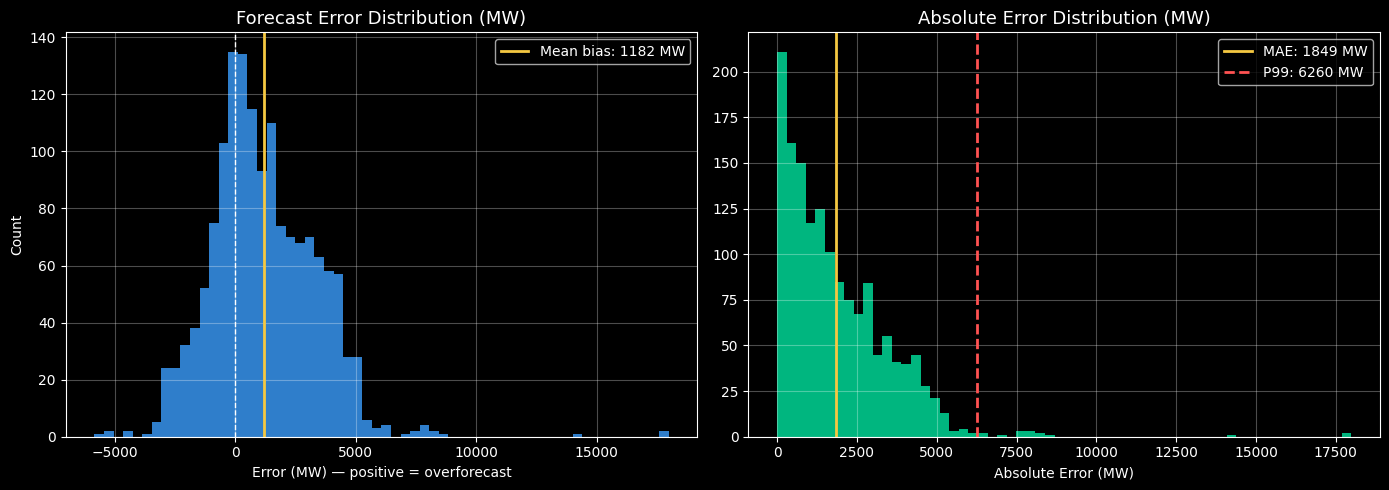

Saved: error_distribution.png


In [6]:
# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(merged['error_mw'], bins=60, color='#3b9eff', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='white', linestyle='--', linewidth=1)
axes[0].axvline(merged['error_mw'].mean(), color='#f5c842', linestyle='-', linewidth=2, label=f'Mean bias: {merged["error_mw"].mean():.0f} MW')
axes[0].set_title('Forecast Error Distribution (MW)', fontsize=13)
axes[0].set_xlabel('Error (MW) — positive = overforecast')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(merged['abs_error_mw'], bins=60, color='#00e5a0', edgecolor='none', alpha=0.8)
axes[1].axvline(merged['abs_error_mw'].mean(),   color='#f5c842', linestyle='-',  linewidth=2, label=f'MAE: {merged["abs_error_mw"].mean():.0f} MW')
axes[1].axvline(merged['abs_error_mw'].quantile(0.99), color='#ff5252', linestyle='--', linewidth=2, label=f'P99: {merged["abs_error_mw"].quantile(0.99):.0f} MW')
axes[1].set_title('Absolute Error Distribution (MW)', fontsize=13)
axes[1].set_xlabel('Absolute Error (MW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_distribution.png')

## 4. Error vs Forecast Horizon

In [7]:
# Build dataset with all horizons (not just 4h)
# For each forecast record, merge with actuals
actuals_hourly = actuals.groupby('startTime_hour')['actual_mw'].mean().reset_index()
actuals_hourly.columns = ['startTime', 'actual_mw']

all_merged = pd.merge(forecasts, actuals_hourly, on='startTime', how='inner')
all_merged['error_mw']     = all_merged['forecast_mw'] - all_merged['actual_mw']
all_merged['abs_error_mw'] = all_merged['error_mw'].abs()

# Bucket by horizon
all_merged['horizon_bucket'] = pd.cut(all_merged['horizon_h'], 
    bins=[0,4,8,12,18,24,30,36,42,48], 
    labels=['0-4h','4-8h','8-12h','12-18h','18-24h','24-30h','30-36h','36-42h','42-48h'])

horizon_stats = all_merged.groupby('horizon_bucket', observed=True)['abs_error_mw'].agg(
    mae='mean', median='median', p99=lambda x: x.quantile(0.99)
).reset_index()

print(horizon_stats.to_string(index=False))

horizon_bucket         mae  median      p99
          0-4h 1836.459677 1318.00 5366.750
          4-8h 1946.816327 1396.00 7505.600
         8-12h 1930.863179 1366.00 7470.900
        12-18h 1922.204446 1395.50 7176.460
        18-24h 1955.463038 1594.00 7246.630
        24-30h 2010.401882 1746.50 7226.505
        30-36h 2080.680444 1868.25 7614.130
        36-42h 2187.154906 2091.50 7560.040
        42-48h 2392.498970 2221.00 7870.740


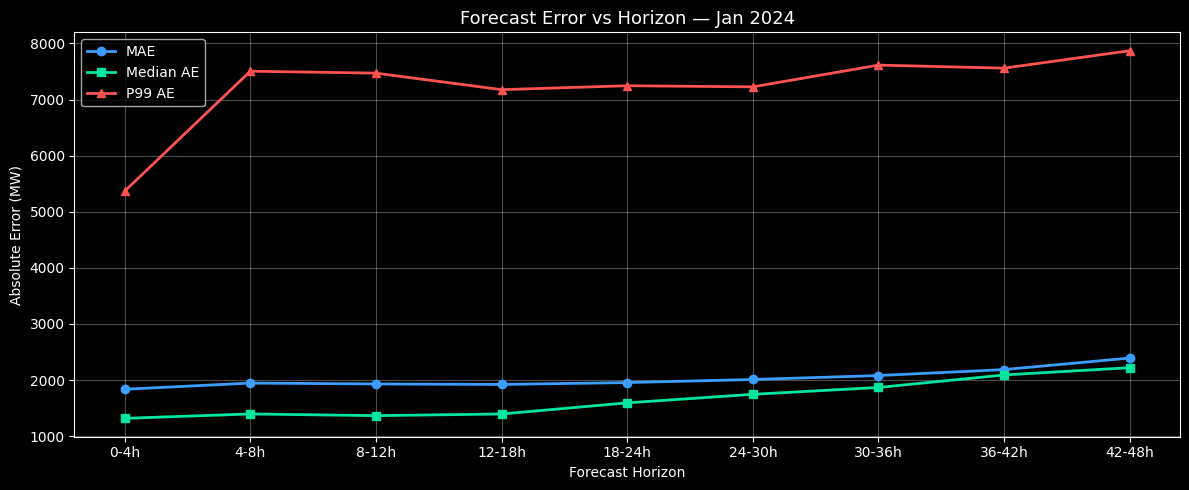

Saved: error_vs_horizon.png


In [8]:
fig, ax = plt.subplots(figsize=(12,5))
x = range(len(horizon_stats))
ax.plot(x, horizon_stats['mae'],    'o-', color='#3b9eff',  linewidth=2, label='MAE')
ax.plot(x, horizon_stats['median'], 's-', color='#00e5a0',  linewidth=2, label='Median AE')
ax.plot(x, horizon_stats['p99'],    '^-', color='#ff5252',  linewidth=2, label='P99 AE')
ax.set_xticks(x)
ax.set_xticklabels(horizon_stats['horizon_bucket'])
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Forecast Error vs Horizon — Jan 2024', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('error_vs_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_vs_horizon.png')

## 5. Error by Time of Day

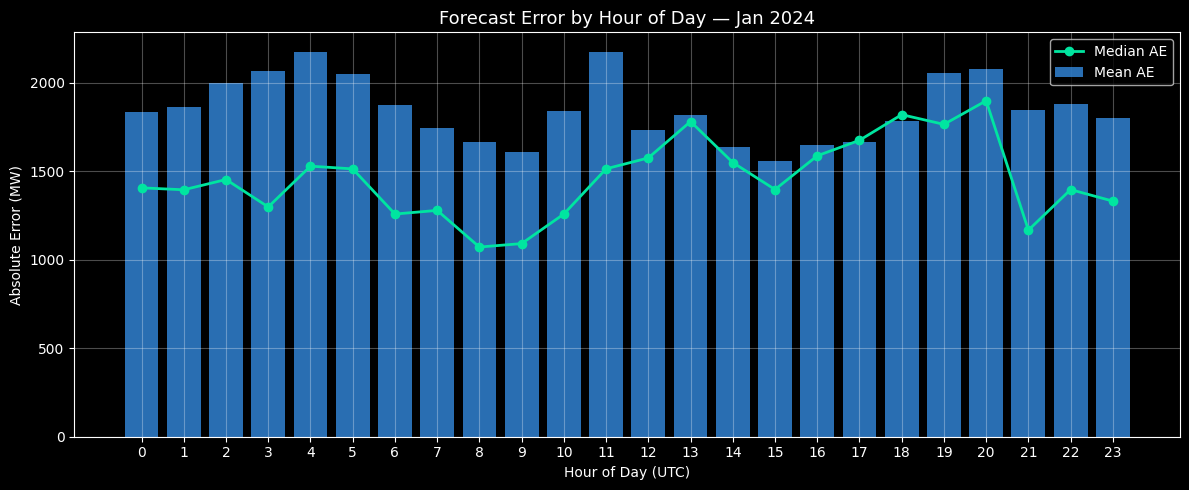

Saved: error_by_hour.png


In [9]:
merged['hour'] = merged['time'].dt.hour
hourly_error = merged.groupby('hour')['abs_error_mw'].agg(['mean','median']).reset_index()

fig, ax = plt.subplots(figsize=(12,5))
ax.bar(hourly_error['hour'], hourly_error['mean'], color='#3b9eff', alpha=0.7, label='Mean AE')
ax.plot(hourly_error['hour'], hourly_error['median'], 'o-', color='#00e5a0', linewidth=2, label='Median AE')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Forecast Error by Hour of Day — Jan 2024', fontsize=13)
ax.set_xticks(range(0,24))
ax.legend()
plt.tight_layout()
plt.savefig('error_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_by_hour.png')

## 6. Summary & Key Findings

- **MAE** tells us the average forecast miss in MW
- **P99** tells us worst-case errors (grid operators need this for reserve planning)
- **Positive mean bias** = model systematically overestimates wind generation
- **Error increases with horizon** — short-term forecasts are more accurate
- **Daytime hours** may show higher errors due to greater wind variability